# Participant-Type Class Distribution

**Feeds:** the choice of evaluation metric for participant-type classification
(Methodology), and RQ3's attribute-level analysis.

The classification score is reported as a **macro-averaged F1** over
participant types rather than as an accuracy. This notebook is the evidence
for that choice. It establishes three things:

1. the participant-type prior in the Lusa corpus is heavily skewed, and
   skewed almost identically in the Portuguese and English versions;
2. model predictions are skewed too, but *differently* -- they over-produce
   some classes and almost never produce others;
3. the frequent classes are also the ones the models type correctly, so any
   instance-weighted summary (accuracy, weighted F1) is carried by them and
   conceals the rest.

Point 3 is what makes accuracy the wrong statistic here: it is not merely
coarse, it is biased in the direction that flatters the result.

All views are **coarse-grained** (any `Pl_*` subtype collapsed into `Loc`),
which is the headline view for the document-level regime, and restricted to
the `cls_*` templates, the only ones that predict a type at all.

In [1]:
import sys
sys.path.insert(0, ".")

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

import _common as c

plt.rcParams["figure.dpi"] = 110
pd.set_option("display.max_rows", 100)
pd.set_option("display.width", 200)

In [2]:
# Both document-level phases, both languages, coarse view, cls_* only.
frames = {}
for stage in c.STAGES:
    for lang in c.LANGUAGE_ORDER:
        d = c.coarsen_types(c.load_detailed(stage, lang))
        frames[(stage, lang)] = d[d["template"].str.contains("cls")]

detailed = pd.concat(frames.values(), ignore_index=True)
print({k: len(v) for k, v in frames.items()})

{('prompt_selection', 'portuguese'): 27260, ('prompt_selection', 'english'): 29255, ('test', 'portuguese'): 65241, ('test', 'english'): 51613}


## 1. The corpus prior

`detailed_results.csv` repeats each gold annotation once per model and
template, so counting it directly would inflate every class by the number of
runs. The prior below is de-duplicated to one row per
`(language, stage, doc_id, participant)` and therefore reports the actual
number of annotated participants.

In [3]:
gold_rows = detailed[detailed["result"].isin(["tp", "fn"])]
gold_rows = gold_rows[gold_rows["annt_type"].notna()]

corpus = (
    gold_rows
    .drop_duplicates(subset=["language", "stage", "doc_id", "token"])
    .copy()
)
corpus["cls"] = corpus["annt_type"].where(
    corpus["annt_type"].isin(c.PROMPT_CLASSES_COARSE), "(other labels)"
)

prior = (
    corpus.groupby(["stage", "language", "cls"]).size().rename("n").reset_index()
)
prior["share"] = prior["n"] / prior.groupby(["stage", "language"])["n"].transform("sum")

pivot_n = prior.pivot_table(index="cls", columns=["stage", "language"], values="n", fill_value=0)
pivot_share = prior.pivot_table(index="cls", columns=["stage", "language"], values="share", fill_value=0.0)
order = pivot_n.sum(axis=1).sort_values(ascending=False).index
print("Annotated participants per class (de-duplicated):")
display(pivot_n.loc[order])
print("\nShare of all annotated participants:")
display((pivot_share.loc[order] * 100).round(1))

Annotated participants per class (de-duplicated):


stage          prompt_selection               test           
language                english portuguese english portuguese
cls                                                          
Per                       172.0      170.0   788.0      788.0
Org                       126.0      119.0   573.0      584.0
Loc                       106.0      107.0   516.0      508.0
Obj                        72.0       70.0   304.0      303.0
Other                      37.0       37.0   213.0      212.0
Nat                        12.0       12.0   101.0      101.0
Fac                         7.0        7.0    73.0       73.0
(other labels)              0.0        0.0    11.0       10.0


Share of all annotated participants:


stage          prompt_selection               test           
language                english portuguese english portuguese
cls                                                          
Per                        32.3       32.6    30.6       30.6
Org                        23.7       22.8    22.2       22.6
Loc                        19.9       20.5    20.0       19.7
Obj                        13.5       13.4    11.8       11.7
Other                       7.0        7.1     8.3        8.2
Nat                         2.3        2.3     3.9        3.9
Fac                         1.3        1.3     2.8        2.8
(other labels)              0.0        0.0     0.4        0.4

The Portuguese and English shares track each other closely, as they must --
the two corpora are parallel versions of the same articles. That matters for
RQ3: any Portuguese/English difference in attribute-level performance cannot
be attributed to the models facing different class distributions.

Saved C:\Users\davib\Desktop\MSc_DataScience\thesis\gpt_struct_me\.claude\worktrees\f1-classification-metric\report\Figures\results\08_gold_class_prior.pdf


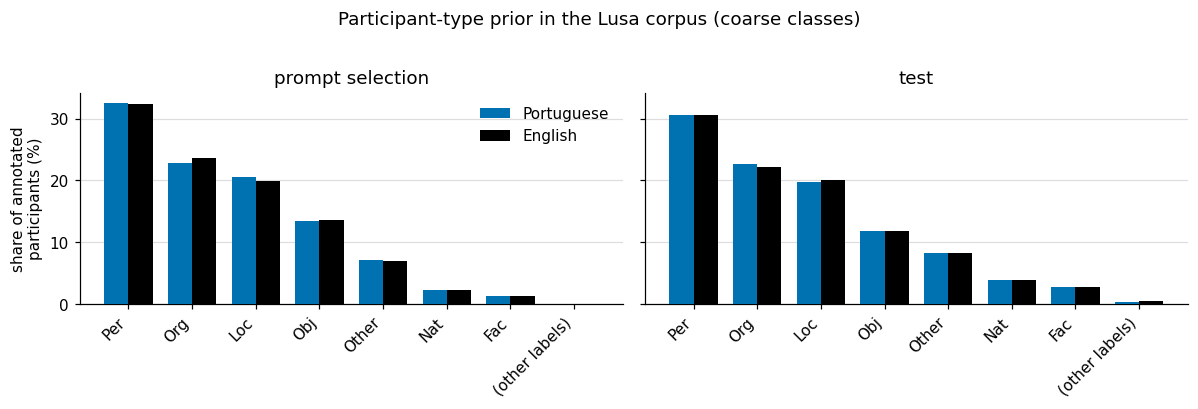

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.6), sharey=True)
for ax, stage in zip(axes, c.STAGES):
    sub = prior[prior["stage"] == stage]
    wide = sub.pivot(index="cls", columns="language", values="share").reindex(order).fillna(0)
    x = np.arange(len(wide))
    width = 0.38
    for i, lang in enumerate(c.LANGUAGE_ORDER):
        if lang not in wide.columns:
            continue
        ax.bar(x + (i - 0.5) * width, wide[lang] * 100, width,
               label=lang.capitalize(), color=c.LANGUAGE_COLORS[lang], zorder=3)
    ax.set_xticks(x)
    ax.set_xticklabels(wide.index, rotation=45, ha="right")
    ax.set_title(stage.replace("_", " "))
    c.style_axis(ax)
axes[0].set_ylabel("share of annotated\nparticipants (%)")
axes[0].legend(frameon=False)
fig.suptitle("Participant-type prior in the Lusa corpus (coarse classes)", y=1.02)
c.save_fig(fig, "08_gold_class_prior")
plt.show()

## 2. What the models actually produce

Three populations, side by side:

* **gold** -- every annotated participant (the prior above);
* **predicted** -- every span a model proposed, by the type it claimed;
* **matched** -- the spans a model located correctly, by their gold type.
  This is the population the classification metric scores over.

The gap between *gold* and *predicted* is the model's class bias. The gap
between *gold* and *matched* shows which classes survive the extraction stage
at all -- if extraction were class-neutral the two would coincide.

In [5]:
pops = []
for source in ("gold", "predicted", "matched"):
    dist = c.class_distribution(detailed, source=source, group_cols=["language"])
    dist["population"] = source
    pops.append(dist)
pops = pd.concat(pops, ignore_index=True)

table = pops.pivot_table(index="cls", columns=["language", "population"],
                         values="share", fill_value=0.0)
table = table.reindex([i for i in order if i in table.index])
print("Share of each population (%), pooled over models and cls_* templates:")
display((table * 100).round(1))

Share of each population (%), pooled over models and cls_* templates:


language       english                   portuguese                  
population        gold matched predicted       gold matched predicted
cls                                                                  
Per               31.2    29.0      25.6       31.2    32.0      25.7
Org               22.8    20.2      18.7       22.7    20.4      19.8
Loc               20.0    28.0      17.1       19.9    24.1      17.7
Obj               12.5    12.4      18.3       12.2    12.9      17.3
Other              7.8     4.5       3.9        7.9     4.1       5.9
Nat                3.3     3.7       2.7        3.4     4.1       2.6
Fac                2.2     1.9       6.3        2.4     2.1       6.1
(other labels)     0.3     0.3       7.5        0.3     0.3       4.8

Saved C:\Users\davib\Desktop\MSc_DataScience\thesis\gpt_struct_me\.claude\worktrees\f1-classification-metric\report\Figures\results\08_class_distribution_shift.pdf


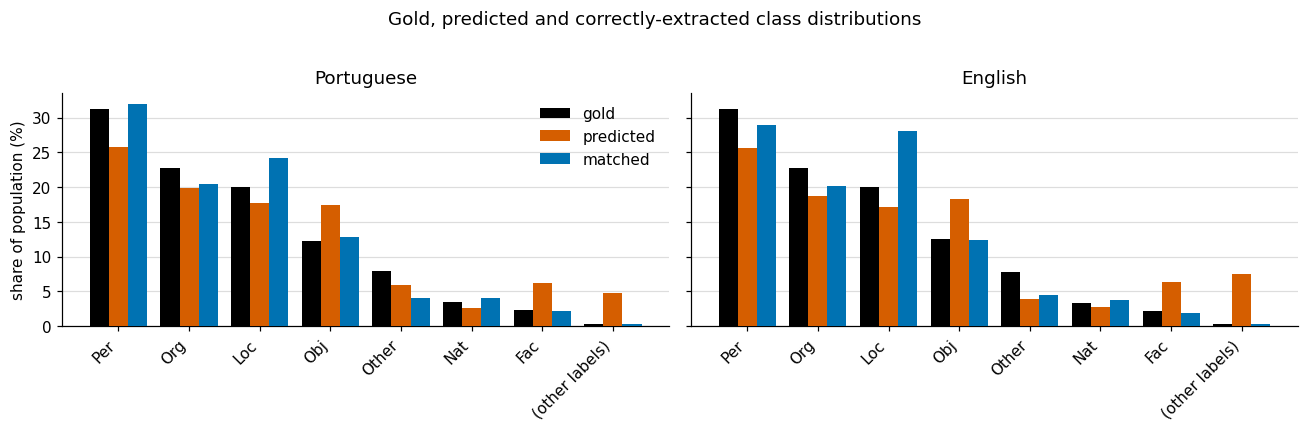

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 3.8), sharey=True)
palette = {"gold": "#000000", "predicted": "#D55E00", "matched": "#0072B2"}
for ax, lang in zip(axes, c.LANGUAGE_ORDER):
    sub = pops[pops["language"] == lang]
    wide = sub.pivot(index="cls", columns="population", values="share")
    wide = wide.reindex([i for i in order if i in wide.index]).fillna(0)
    x = np.arange(len(wide))
    width = 0.27
    for i, pop in enumerate(("gold", "predicted", "matched")):
        if pop not in wide.columns:
            continue
        ax.bar(x + (i - 1) * width, wide[pop] * 100, width,
               label=pop, color=palette[pop], zorder=3)
    ax.set_xticks(x)
    ax.set_xticklabels(wide.index, rotation=45, ha="right")
    ax.set_title(lang.capitalize())
    c.style_axis(ax)
axes[0].set_ylabel("share of population (%)")
axes[0].legend(frameon=False)
fig.suptitle("Gold, predicted and correctly-extracted class distributions", y=1.02)
c.save_fig(fig, "08_class_distribution_shift")
plt.show()

## 3. How skewed is it?

Three standard summaries, computed on the de-duplicated corpus prior:

* **top-class share** and **top-3 share** -- concentration at the head;
* **imbalance ratio** -- most frequent class over least frequent;
* **normalised entropy** -- Shannon entropy divided by `log(k)`, so 1.0 is a
  perfectly uniform distribution and 0.0 a degenerate one.

In [7]:
def imbalance_stats(counts: pd.Series) -> dict:
    counts = counts[counts > 0].sort_values(ascending=False)
    p = counts / counts.sum()
    k = len(counts)
    entropy = float(-(p * np.log(p)).sum() / np.log(k)) if k > 1 else 1.0
    return {
        "classes": k,
        "participants": int(counts.sum()),
        "top_class": counts.index[0],
        "top_share": float(p.iloc[0]),
        "top3_share": float(p.iloc[:3].sum()),
        "rarest_class": counts.index[-1],
        "rarest_share": float(p.iloc[-1]),
        "imbalance_ratio": float(counts.iloc[0] / counts.iloc[-1]),
        "norm_entropy": entropy,
    }

rows = []
for (stage, lang), grp in corpus.groupby(["stage", "language"]):
    counts = grp[grp["cls"].isin(c.PROMPT_CLASSES_COARSE)]["cls"].value_counts()
    rows.append({"stage": stage, "language": lang, **imbalance_stats(counts)})
stats = pd.DataFrame(rows)
display(stats.round(3))

,stage,language,classes,participants,top_class,top_share,top3_share,rarest_class,rarest_share,imbalance_ratio,norm_entropy
0,prompt_selection,english,7,532,Per,0.323,0.759,Fac,0.013,24.571,0.836
1,prompt_selection,portuguese,7,522,Per,0.326,0.759,Fac,0.013,24.286,0.837
2,test,english,7,2568,Per,0.307,0.731,Fac,0.028,10.795,0.877
3,test,portuguese,7,2569,Per,0.307,0.732,Fac,0.028,10.795,0.877


## 4. Frequency and performance are correlated

This is the decisive panel. Each point is one participant type: its support on
the matched-span subset against the F1 the models achieve on it. If frequency
and difficulty were unrelated, the cloud would be flat and an instance-weighted
average would be a fair summary. They are not unrelated -- the frequent classes
are the well-typed ones -- so weighting by instances systematically flatters
the result.

In [8]:
per_class = []
for (stage, lang), frame in frames.items():
    t = c.compute_conditional_type_metrics(frame, per_class=True)
    t["stage"], t["language"] = stage, lang
    per_class.append(t)
per_class = pd.concat(per_class, ignore_index=True)

print("Conditional per-class metrics (matched spans only, coarse):")
display(
    per_class.pivot_table(index="cls", columns=["stage", "language"], values="f1")
    .reindex([i for i in order if i in set(per_class["cls"])]).round(3)
)

rho = per_class[["support", "f1"]].corr(method="spearman").iloc[0, 1]
print(f"\nSpearman correlation between class support and class F1: {rho:.3f}")

Conditional per-class metrics (matched spans only, coarse):


stage    prompt_selection               test           
language          english portuguese english portuguese
cls                                                    
Per                 0.975      0.970   0.919      0.951
Org                 0.932      0.944   0.886      0.899
Loc                 0.878      0.935   0.914      0.932
Obj                 0.809      0.840   0.654      0.763
Other               0.169      0.179   0.161      0.236
Nat                 0.279      0.212   0.162      0.474
Fac                 0.219      0.157   0.414      0.482


Spearman correlation between class support and class F1: 0.778


Saved C:\Users\davib\Desktop\MSc_DataScience\thesis\gpt_struct_me\.claude\worktrees\f1-classification-metric\report\Figures\results\08_support_vs_f1.pdf


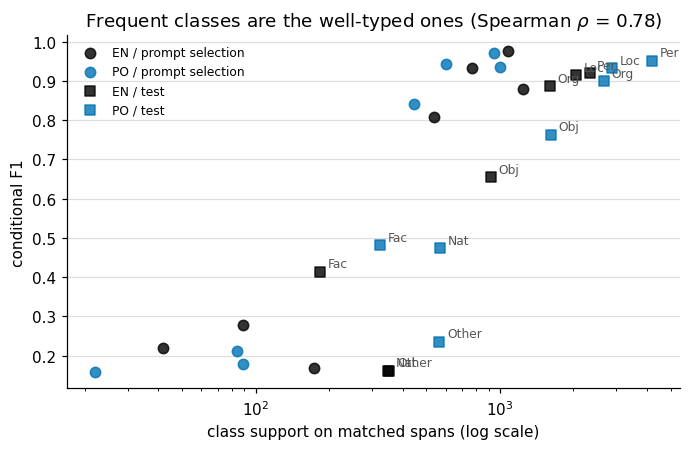

In [9]:
fig, ax = plt.subplots(figsize=(6.4, 4.2))
markers = {"prompt_selection": "o", "test": "s"}
for (stage, lang), grp in per_class.groupby(["stage", "language"]):
    ax.scatter(grp["support"], grp["f1"], s=46, marker=markers[stage],
               color=c.LANGUAGE_COLORS[lang], alpha=0.8, zorder=3,
               label=f"{lang[:2].upper()} / {stage.replace('_', ' ')}")
for _, row in per_class[per_class["stage"] == "test"].iterrows():
    ax.annotate(row["cls"], (row["support"], row["f1"]),
                textcoords="offset points", xytext=(5, 3), fontsize=8, color="#555555")
ax.set_xscale("log")
ax.set_xlabel("class support on matched spans (log scale)")
ax.set_ylabel("conditional F1")
ax.set_title(f"Frequent classes are the well-typed ones (Spearman $\\rho$ = {rho:.2f})")
ax.legend(frameon=False, fontsize=8)
c.style_axis(ax)
c.save_fig(fig, "08_support_vs_f1")
plt.show()

## 5. Consequence for the reported metric

`compute_conditional_type_metrics` returns both figures, so the cost of the
choice is measurable rather than asserted:

* **accuracy** -- the instance-weighted view. On a closed confusion matrix it
  equals micro-precision and micro-recall, and it tracks the support-weighted
  F1 almost exactly.
* **macro F1** -- every participant type weighted equally, `Other` and `Fac`
  included. Both are defined in the annotation guidelines, so a model is
  legitimately accountable for them.

In [10]:
summary = []
for (stage, lang), frame in frames.items():
    s = c.compute_conditional_type_metrics(frame)
    s["stage"], s["language"] = stage, lang
    summary.append(s)
summary = pd.concat(summary, ignore_index=True)

pc = per_class.assign(wf1=per_class["f1"] * per_class["support"])
agg = pc.groupby(["stage", "language"])[["wf1", "support"]].sum().reset_index()
agg["weighted_f1"] = agg["wf1"] / agg["support"]
summary = summary.merge(agg[["stage", "language", "weighted_f1"]], on=["stage", "language"])
summary["accuracy - macro_f1"] = summary["accuracy"] - summary["macro_f1"]

display(summary[["stage", "language", "n_matched", "accuracy", "weighted_f1",
                 "macro_precision", "macro_recall", "macro_f1",
                 "accuracy - macro_f1"]].round(3))

,stage,language,n_matched,accuracy,weighted_f1,macro_precision,macro_recall,macro_f1,accuracy - macro_f1
0,prompt_selection,portuguese,3193,0.885,0.888,0.677,0.634,0.605,0.280
1,prompt_selection,english,3937,0.849,0.854,0.662,0.651,0.609,0.240
2,test,portuguese,12809,0.850,0.847,0.737,0.697,0.677,0.173
3,test,english,7792,0.800,0.800,0.613,0.617,0.587,0.213


Saved C:\Users\davib\Desktop\MSc_DataScience\thesis\gpt_struct_me\.claude\worktrees\f1-classification-metric\report\Figures\results\08_accuracy_vs_macro.pdf


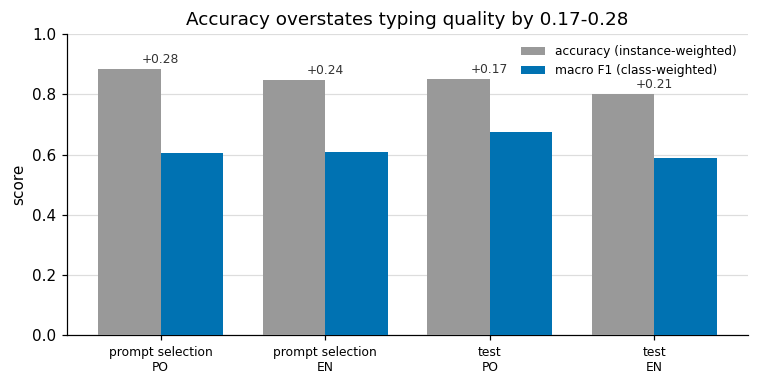

In [11]:
fig, ax = plt.subplots(figsize=(7, 3.6))
labels = summary["stage"].str.replace("_", " ") + "\n" + summary["language"].str[:2].str.upper()
x = np.arange(len(summary))
width = 0.38
ax.bar(x - width / 2, summary["accuracy"], width, label="accuracy (instance-weighted)",
       color="#999999", zorder=3)
ax.bar(x + width / 2, summary["macro_f1"], width, label="macro F1 (class-weighted)",
       color="#0072B2", zorder=3)
for xi, (a, m) in enumerate(zip(summary["accuracy"], summary["macro_f1"])):
    ax.annotate(f"{a - m:+.2f}", (xi, max(a, m) + 0.02), ha="center", fontsize=8, color="#333333")
ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize=8)
ax.set_ylim(0, 1.0)
ax.set_ylabel("score")
ax.set_title("Accuracy overstates typing quality by 0.17-0.28")
ax.legend(frameon=False, fontsize=8)
c.style_axis(ax)
c.save_fig(fig, "08_accuracy_vs_macro")
plt.show()

## Summary

The participant-type distribution is skewed in the corpus (`Per`, `Org` and
`Loc` together account for roughly three quarters of all annotated
participants, with an imbalance ratio of 11-25x), skewed again in what the
models predict, and skewed in a way that correlates with difficulty: the
positive rank correlation between class support and conditional F1 means the
head classes are also the easy ones.

An instance-weighted summary therefore reports mostly the performance on
`Per`, `Org` and `Loc`. Macro-averaging removes that dependence on the prior
and is the figure reported for participant-type classification.